### 이항 분류

In [3]:
import os
os.environ["KERAS_BACKEND"] = "torch"
import keras

# MNIST 데이터 다운로드
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

c:\Users\rapa\miniconda3\envs\vision\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
x_train[0].shape

(28, 28)

In [3]:
from PIL import Image
Image.fromarray(x_train[0])

In [4]:
# 클래스 보기
y_train[0]

np.uint8(5)

In [7]:
# 이항 분류를 위해 3과 4만 이용
import numpy as np
def filter_binary(x, y, neg_cls, pos_cls):
    cond = (y == neg_cls) | (y == pos_cls)
    x_bin = x[cond]
    y_bin = np.where(y[cond] == neg_cls, 0, 1)
    return x_bin, y_bin

In [8]:
x_train_binary, y_train_binary = filter_binary(x_train, y_train, 0, 1)

In [9]:
model = keras.models.Sequential(  # 딥러닝 모형의 구성 요소를 순서대로 정의
    [keras.layers.Rescaling(1/255), #  입력 값의 범위를 0~255에서 0.0 ~ 1.0으로
     keras.layers.Flatten(), #  이미지 평탄화
     keras.layers.Dense(1, activation='sigmoid')]) # 이미지마다 1개의 출력

In [ ]:
# 훈련 설정
# 손실 함수
# 1. MSE(Mean Squared Error): 오차 제곱의 평균 -> 연속변수의 예측에 사용, 이상치에 민감
# 2. Cross Entropy: 두 확률 분포의 차이를 계산 -> 범주형 변수의 예측에 사용
model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.0001), # optimizer SGD(Stochastic Gradient Descent): 일부(=미니배치)를 바탕으로 경사 계산
              loss='binary_crossentropy', metrics=['accuracy'])     # learning rate: 파라미터가 업데이트 되는 정도

# 모멘텀: 파라미터에 속도 개념을 반영 -> 국소 최적에서 벗어날 수 있고, 진동을 억제
# Adam: 학습률을 가변적으로 조정하는 방법
## Adagrad: 많이 가본 방향의 학습률은 낮추고, 새로운 방향의 학습률은 높임

# 훈련
model.fit(x_train_binary, y_train_binary, epochs=5, batch_size=32)

Epoch 1/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9221 - loss: 0.4835
Epoch 2/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9665 - loss: 0.4275
Epoch 3/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9837 - loss: 0.3826
Epoch 4/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9902 - loss: 0.3458
Epoch 5/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9930 - loss: 0.3154


In [11]:
# 테스트
x_test_binary, y_test_binary = filter_binary(x_test, y_test, 0, 1)
model.evaluate(x_test_binary, y_test_binary)

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9957 - loss: 0.2968


[0.2967781722545624, 0.9957447052001953]

In [12]:
import cv2 as cv
x = cv.imread('../data/hand.png', cv.IMREAD_GRAYSCALE) # 이미지 불러오기
x = np.expand_dims(x, axis=0) # 배치 차원 추가
model.predict(x) # 예측

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


array([[0.15416583]], dtype=float32)

In [13]:
## 차원 추가
# expand_dims
np.expand_dims(x, 0) # 0번 차원 확장

# new_axis
x[np.newaxis, 0:28, 0:28] # 0번 차원에 새 축, 1, 2차원은 0~28번값
x[np.newaxis, :, :] # 0번 차원에 새 축, 1, 2차원은 모든 값
x[np.newaxis, ...] # 0번 차원에 새 축, 다른 차원은 모든 값

# reshape
x.reshape(1, 28, 28) # 모양을 1, 28, 28로 변경

array([[[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          96, 222, 222,  96,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0

In [4]:
import os
os.environ["KERAS_BACKEND"] = "torch"
import keras

# fasion MNIST 데이터 다운로드
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [8]:
# 스웨터(2)와 셔츠(6) 이진 분류
x_train_binary, y_train_binary = filter_binary(x_train, y_train, 2, 6)
x_test_binary, y_test_binary = filter_binary(x_test, y_test, 2, 6)

In [9]:
model = keras.models.Sequential(
    [keras.layers.Rescaling(1/255),
     keras.layers.Flatten(),
     keras.layers.Dense(1, activation='sigmoid')])

model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.001),
              loss='binary_crossentropy', metrics=['accuracy'])
model.fit(x_train_binary, y_train_binary, epochs=5, batch_size=32)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6226 - loss: 0.6576
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7004 - loss: 0.6009
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7327 - loss: 0.5701
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7494 - loss: 0.5502
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7661 - loss: 0.5358


In [10]:
y_prob = model.predict(x_test_binary) # 예측 확률
threshold = 0.5 # 문턱값
y_pred = np.where(y_prob >= threshold, 1, 0) # 문턱값보다 크면 1, 아니면 0

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [11]:
# 혼동행렬
from sklearn.metrics import *
y_true = y_test_binary
confusion_matrix(y_true, y_pred)

array([[808, 192],
       [301, 699]])

In [12]:
# Accuracy(정확도)
# 전체 중에 예측이 맞은 비율, (TP + TN)/전체
accuracy_score(y_true, y_pred)

0.7535

In [13]:
# Precision(정밀도)
# 양성 예측 중에 맞은 비율, TP/(TP + FP)
precision_score(y_true, y_pred)

0.7845117845117845

In [14]:
# Recall(재현도)
# 실제 양성 중 찾아낸 비율, TP(TP + FN)
recall_score(y_true, y_pred)

0.699

In [15]:
# Specificity(특이도)
# 실제 음성 중 찾아낸 비율, TN/(TN+FP)
recall_score(y_true, y_pred, pos_label=0)

0.808

In [16]:
# F1
# 정밀도(p)와 재현도(r)의 조화평균, 2pr/(p + r)
f1_score(y_true, y_pred)

0.7392913802221047

In [17]:
# 문턱값
# 문턱값을 비꿔가면서 지표 계산
ths = np.arange(0.1, 0.9, 0.01)
accuracy, precision, recall, specificity, f1 = [], [], [], [], []
for threshold in ths:
    y_pred = np.where(y_prob > threshold, 1, 0)
    accuracy.append(accuracy_score(y_true, y_pred))
    precision.append(precision_score(y_true, y_pred))
    recall.append(recall_score(y_true, y_pred))
    specificity.append(recall_score(y_true, y_pred, pos_label=0))
    f1.append(f1_score(y_true, y_pred))

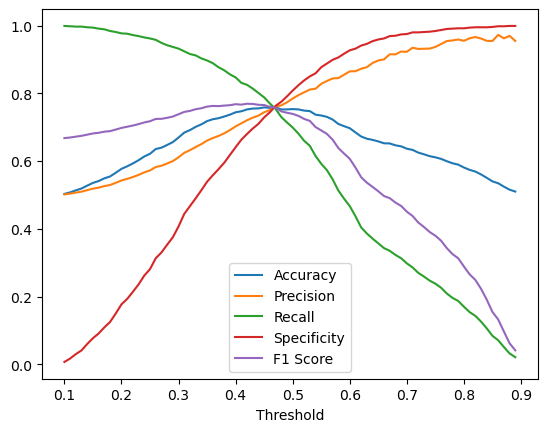

In [ ]:
# 시각화
import matplotlib.pyplot as plt
plt.plot(ths, accuracy, label='Accuracy')
plt.plot(ths, precision, label='Precision')
plt.plot(ths, recall, label='Recall')
plt.plot(ths, specificity, label='Specificity')
plt.plot(ths, f1, label='F1 Score')
plt.xlabel('Threshold')
plt.legend()

# 재현도는 문턱을 낮추면 높아짐
# 정밀도, 특이도는 문턱을 높이면 높아짐

(np.float64(0.4199999999999998), 0.7692307692307693)

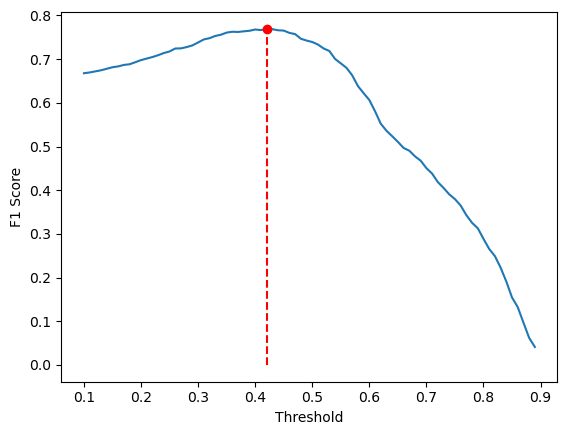

In [19]:
# F1이 가장 높은 문턱값 찾기
i = np.argmax(f1) # 가장 큰 F1 점수의 인덱스
plt.plot(ths, f1)
best_threshold = ths[i] # 가장 큰 F1 점수의 임계값
best_f1 = f1[i] # 가장 큰 F1 점수
plt.plot((best_threshold, best_threshold), (0, best_f1), color='r', linestyle='--')
plt.plot(best_threshold, best_f1, 'ro') # 가장 큰 F1 점수 지점 표시
plt.xlabel('Threshold')
plt.ylabel('F1 Score')

best_threshold, best_f1

### ROC(Receiver Operating Characteristic) 곡선
- 가로축: 1-특이도(FPR), 세로축: 재현도(TPR)
- 문턱값을 변화시키면서 특이도와 재현도의 변화를 곡선으로 표시
- 곡선하 면적(Area Under the Curve; AUC)은 0~1 범위 → 클 수록 높은 성능

0.8303570000000001

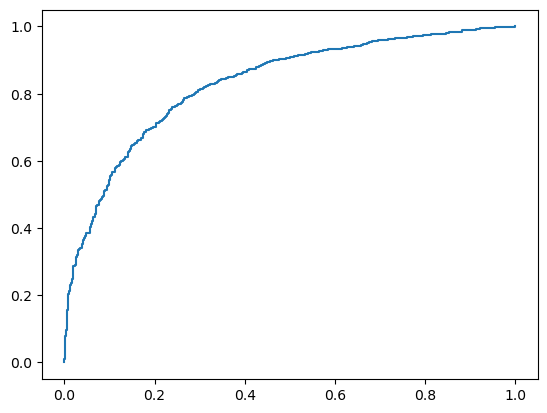

In [20]:
# ROC 곡선
from sklearn.metrics import roc_auc_score, roc_curve
fpr, tpr, threshold = roc_curve(y_true, y_prob)
plt.plot(fpr, tpr)

# AUC
roc_auc_score(y_true, y_prob)